# 1. Proecsamiento de limpieza de datos

In [12]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
datos = {
    'mensaje': [
        # SPAM
        '¡Felicidades! Ganaste un iPhone gratis. Visita http://premios.com para reclamarlo',
        'URGENTE: Tu cuenta fue bloqueada. Llama al 900-123 o entra a http://banco-falso.com',
        'Gana $5000 pesos diarios desde casa sin experiencia. Regístrate ya en www.dinero.com',
        '¡Oferta solo hoy! 90% de descuento. Haz clic aquí http://oferta.net @promos',
        'Préstamo inmediato sin buró. Deposito en 1 hora. Llama al 555-0000',
        'Has sido seleccionado para ganar $10000. Responde este mensaje ahora mismo',
        'GRATIS: Descarga nuestra app y gana premios en efectivo todos los días',
        'Tu paquete no pudo entregarse. Haz clic en http://rastreo-falso.com para reprogramar',
        'Invierte hoy y duplica tu dinero en 24 horas. Solo por hoy en www.inversion.com',
        'Alerta: acceso sospechoso en tu cuenta. Verifica en http://seguridad-falsa.com',
        '¡Último aviso! Cancela tu deuda al 80% menos @finanzas visita www.deudas.com',
        'Gana viajes gratis registrándote en http://viajes-gratis.com código: GRATIS2024',
        'Medicamentos sin receta al 70% de descuento. Envío gratis http://farma.net',
        'Tu número ganó el sorteo nacional. Confirma tu identidad en www.sorteo.com',
        'Aviso de seguridad: Hemos detectado actividad inusual en su cuenta. Verifique en https://seguro-banco.com',
        'Felicidades! Eres el ganador de un premio de 1 millon de dolares. Reclama en www.premio-grande.net',
        'Credito rapido aprobado al instante sin papeleos. Contacta al 555-1122 para mas info',
        'Tu suscripcion vence pronto. Renueva ahora con 50% de descuento en http://renueva-promo.com',
        'Gana criptomonedas gratis con nuestra nueva plataforma. Registrate ya en www.criptofacil.io',
        'Has recibido una herencia inesperada. Para mas detalles, haz clic en este enlace: http://herencia-legal.xyz',
        # HAM
        'Hola, ¿a qué hora nos vemos mañana en el café?',
        'No olvides traer el libro que te presté la semana pasada',
        'La reunión del lunes se cambió para el miércoles a las 10',
        'Mamá dice que la cena estará lista a las 8, ¿puedes venir?',
        'Ya terminé la tarea, ¿me puedes explicar el último ejercicio?',
        'Voy a llegar un poco tarde, hay mucho tráfico en la carretera',
        '¿Viste el partido de anoche? Estuvo increíble el último gol',
        'Recuerda que mañana es el cumpleaños de tu hermana',
        '¿Me puedes ayudar a mover los muebles el sábado por la tarde?',
        'El proyecto quedó muy bien, el jefe estuvo muy contento con el resultado',
        'Paso a recogerte a las 7, avísame si cambias de planes',
        'Ya hice la compra del súper, ¿necesitas que te traiga algo?',
        'Gracias por tu ayuda de ayer, de verdad me salvaste la tarde',
        '¿Quedamos el viernes para estudiar juntos para el examen?',
        '¿Podrías enviarme el reporte que te pedí el lunes, por favor?',
        'El pronóstico del tiempo para el fin de semana es soleado, ¡perfecto para la playa!',
        'Me gustaría programar una cita para la revisión del coche la próxima semana.',
        'He encontrado un artículo muy interesante sobre inteligencia artificial, te lo envío.',
        '¿Sabes dónde puedo encontrar un buen restaurante de comida italiana por aquí?',
        'No te olvides de regar las plantas, es importante para que crezcan bien.'
    ],
    'etiqueta': [
        'spam','spam','spam','spam','spam','spam','spam',
        'spam','spam','spam','spam','spam','spam','spam',
        'spam','spam','spam','spam','spam','spam',
        'ham','ham','ham','ham','ham','ham','ham',
        'ham','ham','ham','ham','ham','ham','ham',
        'ham','ham','ham','ham','ham','ham'
    ]
}


In [6]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['limpio'] = df['mensaje'].apply(limpiar_texto)
df.head()

,mensaje,etiqueta,limpio
0,¡Felicidades! Ganaste un iPhone gratis. Visita...,spam,felicidades ganaste un iphone gratis visita pa...
1,URGENTE: Tu cuenta fue bloqueada. Llama al 900...,spam,urgente tu cuenta fue bloqueada llama al o ent...
2,Gana $5000 pesos diarios desde casa sin experi...,spam,gana pesos diarios desde casa sin experiencia ...
3,¡Oferta solo hoy! 90% de descuento. Haz clic a...,spam,oferta solo hoy de descuento haz clic aquí
4,Préstamo inmediato sin buró. Deposito en 1 hor...,spam,préstamo inmediato sin buró deposito en hora l...


# 2. Tokenización y Eliminación de Stopwords.

In [18]:
pV = set(stopwords.words('spanish'))

def tokenizar(texto):
    tokens = word_tokenize(texto, language='spanish')
    tokens = [t for t in tokens if t not in pV]
    return ' '.join(tokens)

for i in [0, 14]:
    print(f'[{df.loc[i, "etiqueta"].upper()}]')
    print(f'  Limpio   : {df.loc[i, "limpio"]}')
    print(f'  Procesado: {df.loc[i, "procesado"]}')

[SPAM]
  Limpio   : felicidades ganaste un iphone gratis visita para reclamarlo
  Procesado: felicidades ganaste iphone gratis visita reclamarlo
[SPAM]
  Limpio   : aviso de seguridad hemos detectado actividad inusual en su cuenta verifique en
  Procesado: aviso seguridad detectado actividad inusual cuenta verifique


# 3. Entrenamiento del Modelo

Mensajes para entrenar : 32
Mensajes para probar   : 8

✅ Modelo entrenado.
🎯 Exactitud del modelo : 75.0%


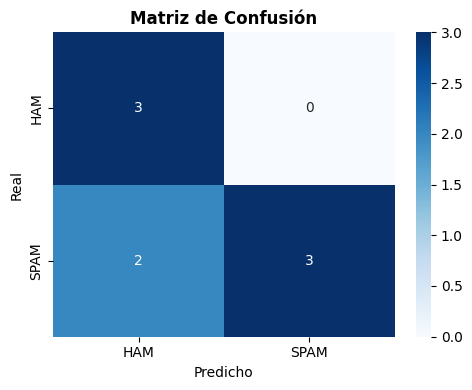


📊 Interpretación de la Matriz de Confusión:
  ✅ HAM  detectado correctamente  (TN): 3
  ✅ SPAM detectado correctamente  (TP): 3
  ⚠️  HAM  clasificado como SPAM   (FP): 0  ← mensaje legítimo bloqueado
  ❌ SPAM clasificado como HAM     (FN): 2  ← spam que no fue detectado


In [20]:

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['procesado'])
y = df['etiqueta']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Mensajes para entrenar : {X_train.shape[0]}')
print(f'Mensajes para probar   : {X_test.shape[0]}')


modelo = MultinomialNB()
modelo.fit(X_train, y_train)
print('\n✅ Modelo entrenado.')


predicciones = modelo.predict(X_test)
exactitud    = accuracy_score(y_test, predicciones)
print(f'🎯 Exactitud del modelo : {exactitud * 100:.1f}%')


cm = confusion_matrix(y_test, predicciones, labels=['ham', 'spam'])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HAM', 'SPAM'],
            yticklabels=['HAM', 'SPAM'])
plt.title('Matriz de Confusión', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print('\n📊 Interpretación de la Matriz de Confusión:')
print(f'  ✅ HAM  detectado correctamente  (TN): {tn}')
print(f'  ✅ SPAM detectado correctamente  (TP): {tp}')
print(f'  ⚠️  HAM  clasificado como SPAM   (FP): {fp}  ← mensaje legítimo bloqueado')
print(f'  ❌ SPAM clasificado como HAM     (FN): {fn}  ← spam que no fue detectado')

# 4. Hacer Predicciones en Tiempo Real: Poner resultado y el nivel de confianza del mismo.

In [21]:
def predecir(mensaje):
    limpio    = limpiar_texto(mensaje)
    procesado = tokenizar(limpio)
    vector    = tfidf.transform([procesado])

    resultado     = modelo.predict(vector)[0]
    probabilidades = modelo.predict_proba(vector)[0]
    confianza_ham  = probabilidades[0] * 100
    confianza_spam = probabilidades[1] * 100

    emoji = '🚨 SPAM' if resultado == 'spam' else '✅ HAM'
    print(f'Mensaje  : {mensaje}')
    print(f'Resultado: {emoji}')
    print(f'Confianza: HAM {confianza_ham:.1f}%  |  SPAM {confianza_spam:.1f}%')
    print('-' * 55)


print('PREDICCIONES')
predecir('¡Ganaste un viaje gratis! Entra a www.premio.com ahora')
predecir('¿Puedes pasarme los apuntes de la clase de hoy?')
predecir('Último aviso: verifica tu cuenta o será cancelada')
predecir('Nos vemos el viernes en el cumpleaños de Carlos')
predecir('Oferta solo hoy 80% de descuento llama al 555-9999')
predecir('Ya llegué a casa, avísame cuando salgas')

🔍 PREDICCIONES
-------------------------------------------------------
Mensaje  : ¡Ganaste un viaje gratis! Entra a www.premio.com ahora
Resultado: 🚨 SPAM
Confianza: HAM 27.6%  |  SPAM 72.4%
-------------------------------------------------------
Mensaje  : ¿Puedes pasarme los apuntes de la clase de hoy?
Resultado: ✅ HAM
Confianza: HAM 51.8%  |  SPAM 48.2%
-------------------------------------------------------
Mensaje  : Último aviso: verifica tu cuenta o será cancelada
Resultado: 🚨 SPAM
Confianza: HAM 32.1%  |  SPAM 67.9%
-------------------------------------------------------
Mensaje  : Nos vemos el viernes en el cumpleaños de Carlos
Resultado: ✅ HAM
Confianza: HAM 62.9%  |  SPAM 37.1%
-------------------------------------------------------
Mensaje  : Oferta solo hoy 80% de descuento llama al 555-9999
Resultado: 🚨 SPAM
Confianza: HAM 26.6%  |  SPAM 73.4%
-------------------------------------------------------
Mensaje  : Ya llegué a casa, avísame cuando salgas
Resultado: ✅ HAM
Confia